# 05 — Cost-Aware Diagnostic Backtest

Evaluate held-out predictions from the three synthetic models using executable top-of-book prices and round-trip fees.

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / "src").exists():
    raise FileNotFoundError("Run this notebook from the repository or notebooks directory.")

sys.path.insert(0, str(REPO_ROOT / "src"))
PROCESSED = REPO_ROOT / "data/processed/synthetic_h50"
RUNS = {
    "Baseline": REPO_ROOT / "outputs/synthetic_baseline_h50",
    "DeepLOB": REPO_ROOT / "outputs/synthetic_deeplob_h50",
    "Transformer": REPO_ROOT / "outputs/synthetic_transformer_h50",
}
CONFIDENCE = 0.50
FEE_BPS = 0.8

print("Repository:", REPO_ROOT)
print("Processed data:", PROCESSED)
print(f"Confidence: {CONFIDENCE:.2f} | Fee: {FEE_BPS:.1f} bps per side")


Repository: /home/shuaigou2025/projects/cost-aware-limit-order-book-forecasting
Processed data: /home/shuaigou2025/projects/cost-aware-limit-order-book-forecasting/data/processed/synthetic_h50
Confidence: 0.50 | Fee: 0.8 bps per side


## Execution rule

At each test event `t`, trade only when the largest predicted class probability is at least `0.50` and the predicted class is directional. With best ask `A[t]`, best bid `B[t]`, horizon `h = 50`, and per-side fee `f = 0.8 / 10,000`:

$$r_t^{long} = (B[t+h] - A[t]) / A[t] - 2f$$

$$r_t^{short} = (B[t] - A[t+h]) / B[t] - 2f$$

The bid/ask choice already includes spread cost. For active trades `r_1, ..., r_k`, the plotted quantity is `C_k = r_1 + ... + r_k`; it is not compounded equity.

## Run diagnostic backtests
Notebook 04 must first produce `test_predictions.npz` for each model. The following cells refresh the saved backtest metrics and per-trade returns.

### Baseline logistic regression

In [2]:
subprocess.run(
    [
        sys.executable,
        "scripts/run_backtest.py",
        "--processed-dir",
        str(PROCESSED.relative_to(REPO_ROOT)),
        "--run-dir",
        str(RUNS["Baseline"].relative_to(REPO_ROOT)),
        "--confidence",
        str(CONFIDENCE),
        "--fee-bps",
        str(FEE_BPS),
    ],
    cwd=REPO_ROOT,
    check=True,
)

{
  "n_signals": 1051,
  "n_trades": 656,
  "trade_rate": 0.6241674595623216,
  "mean_return_per_trade": 0.002692720147978834,
  "hit_rate": 0.7652439024390244,
  "sum_independent_returns": 1.766424417074115,
  "max_drawdown_independent_returns": -0.19086162437226645,
  "confidence": 0.5,
  "fee_bps": 0.8,
  "warning": "Independent overlapping fixed-horizon trades; immediate fills assumed."
}


CompletedProcess(args=['/home/shuaigou2025/projects/cost-aware-limit-order-book-forecasting/.venv/bin/python', 'scripts/run_backtest.py', '--processed-dir', 'data/processed/synthetic_h50', '--run-dir', 'outputs/synthetic_baseline_h50', '--confidence', '0.5', '--fee-bps', '0.8'], returncode=0)

### DeepLOB

In [3]:
subprocess.run(
    [
        sys.executable,
        "scripts/run_backtest.py",
        "--processed-dir",
        str(PROCESSED.relative_to(REPO_ROOT)),
        "--run-dir",
        str(RUNS["DeepLOB"].relative_to(REPO_ROOT)),
        "--confidence",
        str(CONFIDENCE),
        "--fee-bps",
        str(FEE_BPS),
    ],
    cwd=REPO_ROOT,
    check=True,
)

{
  "n_signals": 1051,
  "n_trades": 1024,
  "trade_rate": 0.9743101807802094,
  "mean_return_per_trade": 0.0021572826005429846,
  "hit_rate": 0.6630859375,
  "sum_independent_returns": 2.2090573829560163,
  "max_drawdown_independent_returns": -0.1662427815235188,
  "confidence": 0.5,
  "fee_bps": 0.8,
  "warning": "Independent overlapping fixed-horizon trades; immediate fills assumed."
}


CompletedProcess(args=['/home/shuaigou2025/projects/cost-aware-limit-order-book-forecasting/.venv/bin/python', 'scripts/run_backtest.py', '--processed-dir', 'data/processed/synthetic_h50', '--run-dir', 'outputs/synthetic_deeplob_h50', '--confidence', '0.5', '--fee-bps', '0.8'], returncode=0)

### Transformer

In [4]:
subprocess.run(
    [
        sys.executable,
        "scripts/run_backtest.py",
        "--processed-dir",
        str(PROCESSED.relative_to(REPO_ROOT)),
        "--run-dir",
        str(RUNS["Transformer"].relative_to(REPO_ROOT)),
        "--confidence",
        str(CONFIDENCE),
        "--fee-bps",
        str(FEE_BPS),
    ],
    cwd=REPO_ROOT,
    check=True,
)

{
  "n_signals": 1051,
  "n_trades": 919,
  "trade_rate": 0.8744053282588011,
  "mean_return_per_trade": 0.0018712129290151187,
  "hit_rate": 0.6583242655059848,
  "sum_independent_returns": 1.719644681764894,
  "max_drawdown_independent_returns": -0.2608601119573689,
  "confidence": 0.5,
  "fee_bps": 0.8,
  "warning": "Independent overlapping fixed-horizon trades; immediate fills assumed."
}


CompletedProcess(args=['/home/shuaigou2025/projects/cost-aware-limit-order-book-forecasting/.venv/bin/python', 'scripts/run_backtest.py', '--processed-dir', 'data/processed/synthetic_h50', '--run-dir', 'outputs/synthetic_transformer_h50', '--confidence', '0.5', '--fee-bps', '0.8'], returncode=0)

## Compare diagnostic results

The table and curves below use the saved artifacts for every available model. Curves have different lengths because models generate different numbers of active trades.

In [5]:
rows = []
missing = []
for model, run_dir in RUNS.items():
    metrics_path = run_dir / "backtest_metrics.json"
    if not metrics_path.exists():
        missing.append(model)
        continue

    metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
    rows.append(
        {
            "Model": model,
            "Signals": metrics["n_signals"],
            "Trades": metrics["n_trades"],
            "Trade rate": metrics["trade_rate"],
            "Mean return (bps)": metrics["mean_return_per_trade"] * 10_000,
            "Hit rate": metrics["hit_rate"],
            "Sum of returns": metrics["sum_independent_returns"],
            "Max drawdown": metrics["max_drawdown_independent_returns"],
        }
    )

if missing:
    print("Missing backtest metrics for:", ", ".join(missing))

if rows:
    comparison = pd.DataFrame(rows).set_index("Model")
    display(
        comparison.style.format(
            {
                "Trade rate": "{:.1%}",
                "Mean return (bps)": "{:.2f}",
                "Hit rate": "{:.1%}",
                "Sum of returns": "{:.3f}",
                "Max drawdown": "{:.3f}",
            }
        )
    )
else:
    print("Run the diagnostic backtests above first.")

,Signals,Trades,Trade rate,Mean return (bps),Hit rate,Sum of returns,Max drawdown
Model,,,,,,,
Baseline,1051,656,62.4%,26.93,76.5%,1.766,-0.191
DeepLOB,1051,1024,97.4%,21.57,66.3%,2.209,-0.166
Transformer,1051,919,87.4%,18.71,65.8%,1.720,-0.261


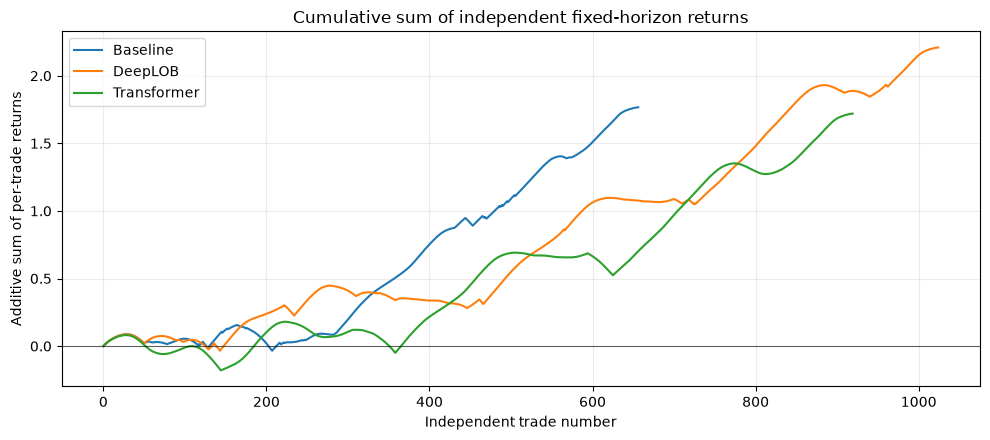

In [6]:
curves = {}
for model, run_dir in RUNS.items():
    returns_path = run_dir / "diagnostic_trade_returns.npy"
    if returns_path.exists():
        trade_returns = np.load(returns_path)
        curves[model] = np.r_[0.0, np.cumsum(trade_returns)]

if curves:
    fig, ax = plt.subplots(figsize=(10, 4.5))
    for model, cumulative_returns in curves.items():
        ax.plot(cumulative_returns, label=model)
    ax.axhline(0.0, color="black", linewidth=0.8, alpha=0.6)
    ax.set_title("Cumulative sum of independent fixed-horizon returns")
    ax.set_xlabel("Independent trade number")
    ax.set_ylabel("Additive sum of per-trade returns")
    ax.grid(alpha=0.25)
    ax.legend()
    fig.tight_layout()
    plt.show()
else:
    print("No diagnostic return files found. Run the backtests above first.")